In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tomizzz","key":"6c941ce14f753c97939939eb6b2c4cad"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d jonathanoheix/face-expression-recognition-dataset

Dataset URL: https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset
License(s): unknown
100% 121M/121M [00:01<00:00, 86.2MB/s]



In [ ]:
!unzip face-expression-recognition-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: images/validation/fear/8797.jpg  
  inflating: images/validation/fear/8818.jpg  
  inflating: images/validation/fear/886.jpg  
  inflating: images/validation/fear/9037.jpg  
  inflating: images/validation/fear/9040.jpg  
  inflating: images/validation/fear/9101.jpg  
  inflating: images/validation/fear/911.jpg  
  inflating: images/validation/fear/9179.jpg  
  inflating: images/validation/fear/9205.jpg  
  inflating: images/validation/fear/9232.jpg  
  inflating: images/validation/fear/9251.jpg  
  inflating: images/validation/fear/9261.jpg  
  inflating: images/validation/fear/9281.jpg  
  inflating: images/validation/fear/9302.jpg  
  inflating: images/validation/fear/9333.jpg  
  inflating: images/validation/fear/9369.jpg  
  inflating: images/validation/fear/9370.jpg  
  inflating: images/validation/fear/9474.jpg  
  inflating: images/validation/fear/949.jpg  
  inflating: images/validation/fear/9602.jpg  
  inflating:

### Installing PyTorch and other dependencies

In [ ]:
# Install PyTorch and torchvision
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install scikit-learn matplotlib


Looking in indexes: https://download.pytorch.org/whl/cu118


### Importing Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Data Loading and Preprocessing for PyTorch

We'll use `torchvision.datasets.ImageFolder` to load our image data and `torchvision.transforms` for preprocessing and augmentation. The `DataLoader` will then handle batching and shuffling.

In [ ]:
IMG_SIZE = 48
BATCH_SIZE = 64

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # Ensure grayscale
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), # Increased rotation
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)), # Increased translation
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Added ColorJitter
    transforms.Pad(padding=4),
    transforms.RandomCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) # Normalize for grayscale images
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # Ensure grayscale
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.ImageFolder('images/train', transform=train_transforms)
val_dataset = datasets.ImageFolder('images/validation', transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Get class labels from the dataset
emotion_labels = train_dataset.classes
num_classes = len(emotion_labels)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Detected emotion labels: {emotion_labels}")
print(f"Number of classes: {num_classes}")

Number of training samples: 28821
Number of validation samples: 7066
Detected emotion labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


### Define PyTorch CNN Model Architecture

This CNN architecture is adapted from the previous TensorFlow model, using PyTorch's `nn.Module`.

In [ ]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes):
        super(EmotionCNN, self).__init__()
        # Input: 1 channel (grayscale), 48x48

        # Block 1
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(0.25) # Reverted dropout

        # Block 2
        self.conv2 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(128)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout(0.25) # Reverted dropout

        # Block 3
        self.conv3 = nn.Conv2d(128, 512, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(512)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout(0.25) # Reverted dropout

        # Block 4
        self.conv4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout4 = nn.Dropout(0.25) # Reverted dropout

        # Fully Connected Layers
        # Calculate input features for the first dense layer
        # After 4 MaxPool2d layers (stride=2), image size becomes 48 / (2^4) = 48/16 = 3x3
        self.fc_input_features = 512 * (IMG_SIZE // (2**4)) * (IMG_SIZE // (2**4)) # 512 * 3 * 3

        self.fc1 = nn.Linear(self.fc_input_features, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.relu_fc1 = nn.ReLU()
        self.dropout_fc1 = nn.Dropout(0.25) # Reverted dropout

        self.fc2 = nn.Linear(256, 512)
        self.bn_fc2 = nn.BatchNorm1d(512)
        self.relu_fc2 = nn.ReLU()
        self.dropout_fc2 = nn.Dropout(0.25) # Reverted dropout

        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.dropout1(self.pool1(self.relu1(self.bn1(self.conv1(x)))))
        x = self.dropout2(self.pool2(self.relu2(self.bn2(self.conv2(x)))))
        x = self.dropout3(self.pool3(self.relu3(self.bn3(self.conv3(x)))))
        x = self.dropout4(self.pool4(self.relu4(self.bn4(self.conv4(x)))))

        x = x.view(-1, self.fc_input_features) # Flatten

        x = self.dropout_fc1(self.relu_fc1(self.bn_fc1(self.fc1(x))))
        x = self.dropout_fc2(self.relu_fc2(self.bn_fc2(self.fc2(x))))

        x = self.fc3(x)
        return x

model = EmotionCNN(num_classes=num_classes).to(device)
print(model)

EmotionCNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv2): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(128, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout(p=0.25, inplace=False)
  (conv4): Conv2d(512, 512, kernel_size

### Define Loss Function, Optimizer, and Training Parameters

We'll use Cross-Entropy Loss and the Adam optimizer. We'll also calculate class weights to address data imbalance.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Calculate class weights for imbalanced datasets
# Get class counts from training dataset
class_counts = np.array([0] * num_classes)
for _, label_idx in train_dataset.samples:
    class_counts[label_idx] += 1

# Compute inverse class frequencies
total_samples = sum(class_counts)
class_weights = total_samples / (num_classes * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

EPOCHS = 50 # Set to a maximum of 50 epochs as requested
LEARNING_RATE = 0.0001

criterion = nn.CrossEntropyLoss(weight=class_weights) # Use class weights in loss function
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5) # Added weight_decay

# Add a learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)

print("Class Weights:", class_weights.cpu().numpy())

Class Weights: [1.0311259  9.4433155  1.0034817  0.57471883 0.8264323  0.8337962
 1.2846445 ]


### Training and Validation Loop

This section contains the core logic for training the PyTorch model and evaluating it on the validation set during each epoch.

In [ ]:
best_val_accuracy = 0.0
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    # Training Phase
    model.train() # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_accuracy = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Validation Phase
    model.eval() # Set model to evaluation mode
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_accuracy = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    # Step the learning rate scheduler
    scheduler.step(epoch_val_loss)

    print(f'Epoch {epoch+1}/{EPOCHS} | ' \
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | ' \
          f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}')

    # Save the model if validation accuracy improves
    if epoch_val_accuracy > best_val_accuracy:
        best_val_accuracy = epoch_val_accuracy
        torch.save(model.state_dict(), 'best_emotion_model_weights.pth')
        print(f"  --> Saved Best Model (Epoch {epoch+1}) with Val Accuracy: {best_val_accuracy:.4f}")

print("Finished Training!")

Epoch 1/50 | Train Loss: 1.9669, Train Acc: 0.1746 | Val Loss: 2.0251, Val Acc: 0.0188
  --> Saved Best Model (Epoch 1) with Val Accuracy: 0.0188
Epoch 2/50 | Train Loss: 1.9394, Train Acc: 0.1893 | Val Loss: 1.8513, Val Acc: 0.2771
  --> Saved Best Model (Epoch 2) with Val Accuracy: 0.2771
Epoch 3/50 | Train Loss: 1.9175, Train Acc: 0.2120 | Val Loss: 1.8846, Val Acc: 0.1911
Epoch 4/50 | Train Loss: 1.8560, Train Acc: 0.2514 | Val Loss: 1.7122, Val Acc: 0.3275
  --> Saved Best Model (Epoch 4) with Val Accuracy: 0.3275
Epoch 5/50 | Train Loss: 1.7823, Train Acc: 0.2929 | Val Loss: 1.6182, Val Acc: 0.3796
  --> Saved Best Model (Epoch 5) with Val Accuracy: 0.3796
Epoch 6/50 | Train Loss: 1.7216, Train Acc: 0.3286 | Val Loss: 1.6305, Val Acc: 0.3808
  --> Saved Best Model (Epoch 6) with Val Accuracy: 0.3808
Epoch 7/50 | Train Loss: 1.6701, Train Acc: 0.3507 | Val Loss: 1.5259, Val Acc: 0.4125
  --> Saved Best Model (Epoch 7) with Val Accuracy: 0.4125
Epoch 8/50 | Train Loss: 1.6328, Trai

### Plotting Training History

Visualize the training and validation loss and accuracy over epochs.

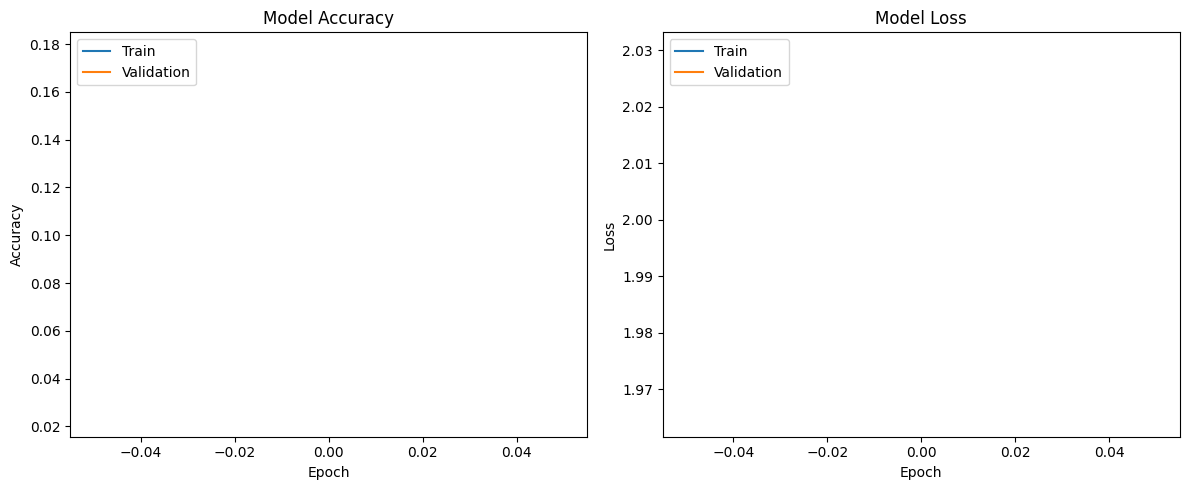

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(train_accuracies)
plt.plot(val_accuracies)
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(train_losses)
plt.plot(val_losses)
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


### Model Evaluation

Evaluate the trained model on the validation set and display a confusion matrix and classification report.

Overall Validation Accuracy: 0.1149

Classification Report:
              precision    recall  f1-score   support

       angry       0.14      0.44      0.21       960
     disgust       0.01      0.06      0.01       111
        fear       0.17      0.00      0.00      1018
       happy       0.00      0.00      0.00      1825
     neutral       0.75      0.00      0.00      1216
         sad       0.18      0.11      0.14      1139
    surprise       0.11      0.32      0.17       797

    accuracy                           0.11      7066
   macro avg       0.19      0.13      0.08      7066
weighted avg       0.21      0.11      0.07      7066



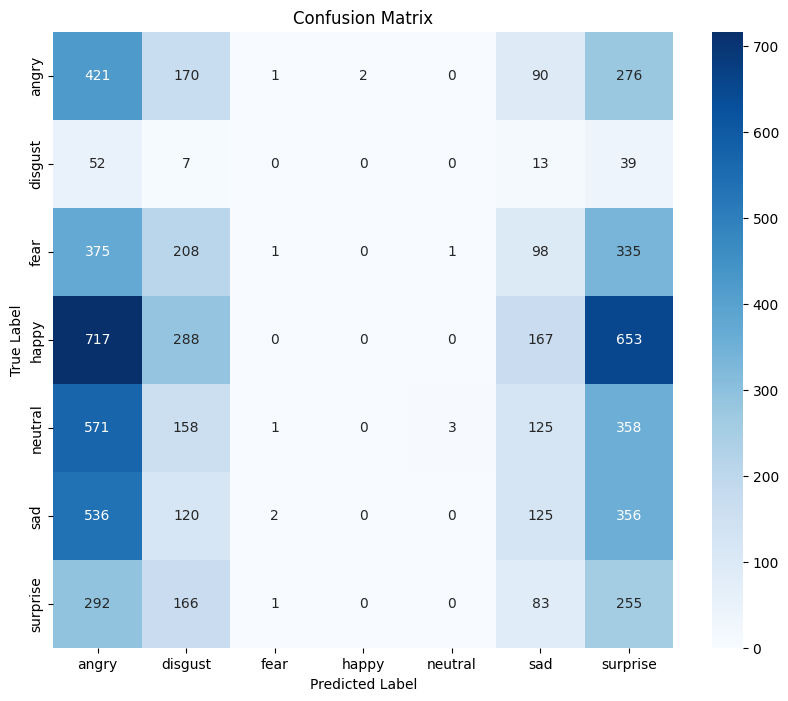

In [ ]:
# Load the best model weights for final evaluation
model.load_state_dict(torch.load('best_emotion_model_weights.pth'))
model.eval() # Set model to evaluation mode

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate overall accuracy
overall_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Overall Validation Accuracy: {overall_accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=emotion_labels))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


### Test Model on a Demo Example

Let's test the trained model on a single, randomly selected image from the validation set to see its performance firsthand.

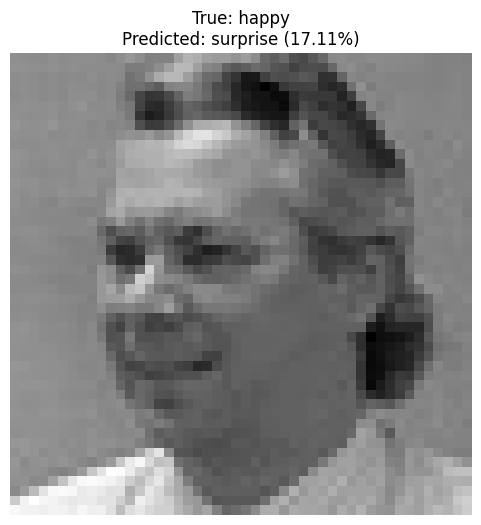

In [ ]:
from PIL import Image
import random

# Get a random image path from the validation set
random_idx = random.randint(0, len(val_dataset) - 1)
sample_image_path, true_label_idx = val_dataset.samples[random_idx]

# Load the image using PIL (ImageFolder already handles this, but for single image loading)
img = Image.open(sample_image_path).convert('L') # Convert to grayscale

# Apply the validation transforms to the single image
preprocessed_img = val_transforms(img)

# Add a batch dimension (model expects batches)
preprocessed_img = preprocessed_img.unsqueeze(0).to(device)

# Set model to evaluation mode and make prediction
model.eval()
with torch.no_grad():
    outputs = model(preprocessed_img)
    probabilities = torch.softmax(outputs, dim=1)
    predicted_prob, predicted_label_idx = torch.max(probabilities, 1)

predicted_emotion = emotion_labels[predicted_label_idx.item()]
true_emotion = emotion_labels[true_label_idx]
confidence = predicted_prob.item() * 100

# Display the image and prediction
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray') # Display the original grayscale image
plt.title(f"True: {true_emotion}\nPredicted: {predicted_emotion} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

### Saving the Model and Labels for Local Deployment

First, you need to save the trained model's weights and the emotion labels so you can use them on your local machine. We've already saved `best_emotion_model_weights.pth` during training. Now, let's also save the `emotion_labels`.

In [ ]:
import json

# Save emotion labels to a JSON file
with open('emotion_labels.json', 'w') as f:
    json.dump(emotion_labels, f)

print("Model weights 'best_emotion_model_weights.pth' and emotion labels 'emotion_labels.json' saved.")
print("You can now download these files from your Colab environment (File Explorer on the left panel).")

Model weights 'best_emotion_model_weights.pth' and emotion labels 'emotion_labels.json' saved.
You can now download these files from your Colab environment (File Explorer on the left panel).


### Re-plotting Training History

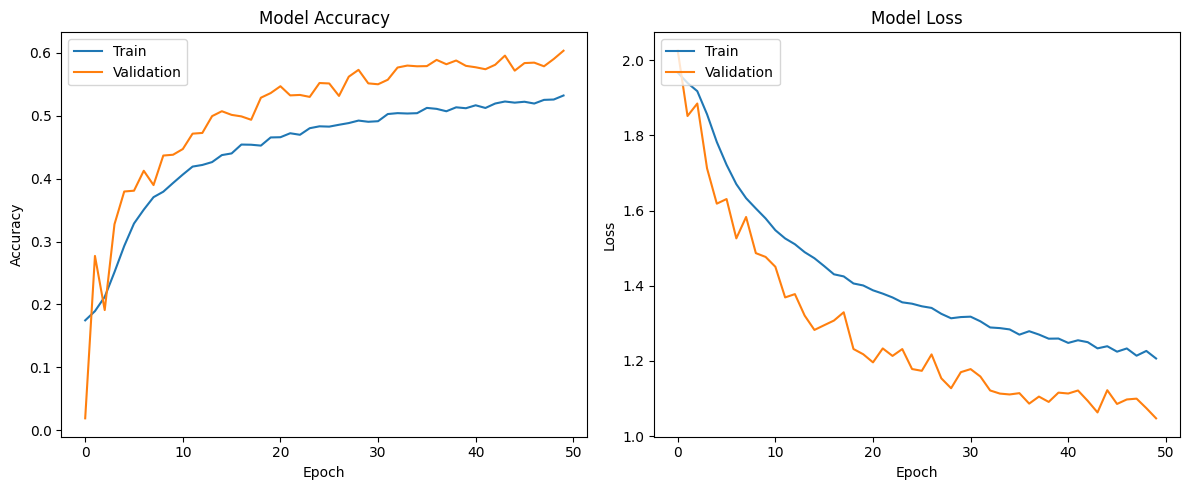

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(train_accuracies)
plt.plot(val_accuracies)
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(train_losses)
plt.plot(val_losses)
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

### Re-evaluating Model Performance

Overall Validation Accuracy: 0.6035

Classification Report:
              precision    recall  f1-score   support

       angry       0.55      0.43      0.48       960
     disgust       0.27      0.77      0.40       111
        fear       0.53      0.26      0.35      1018
       happy       0.85      0.81      0.83      1825
     neutral       0.50      0.66      0.57      1216
         sad       0.47      0.52      0.50      1139
    surprise       0.70      0.78      0.74       797

    accuracy                           0.60      7066
   macro avg       0.55      0.60      0.55      7066
weighted avg       0.61      0.60      0.60      7066



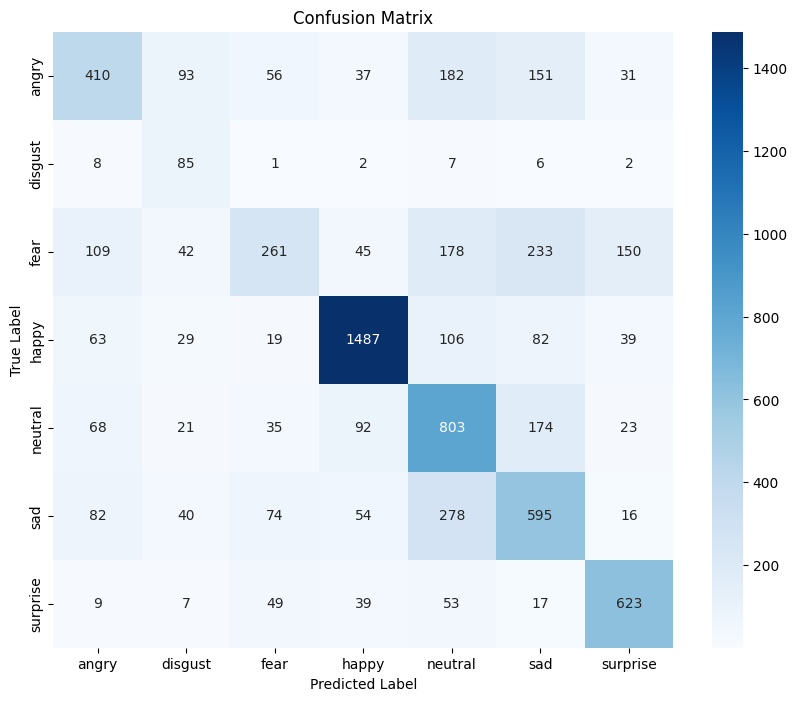

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch
import matplotlib.pyplot as plt

# Load the best model weights for final evaluation
model.load_state_dict(torch.load('best_emotion_model_weights.pth'))
model.eval() # Set model to evaluation mode

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate overall accuracy
overall_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Overall Validation Accuracy: {overall_accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=emotion_labels))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Local Machine Setup and Inference Script

Once you have downloaded `best_emotion_model_weights.pth` and `emotion_labels.json` to your local machine, follow these steps:

1.  **Install Python and necessary libraries:**
    Make sure you have Python installed (preferably Python 3.8+). Then, install PyTorch, OpenCV, NumPy, and Pillow:
    ```bash
    pip install torch torchvision opencv-python numpy Pillow
    ```

2.  **Save the `EmotionCNN` class definition locally.** Create a file named `model_architecture.py` and paste the `EmotionCNN` class code into it. This is crucial because `torch.load` only loads the state dictionary, not the model's structure.

    ```python
    # model_architecture.py
    import torch.nn as nn

    class EmotionCNN(nn.Module):
        def __init__(self, num_classes):
            super(EmotionCNN, self).__init__()
            # Input: 1 channel (grayscale), 48x48

            # Block 1
            self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
            self.bn1 = nn.BatchNorm2d(64)
            self.relu1 = nn.ReLU()
            self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.dropout1 = nn.Dropout(0.25) # Reverted dropout

            # Block 2
            self.conv2 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
            self.bn2 = nn.BatchNorm2d(128)
            self.relu2 = nn.ReLU()
            self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.dropout2 = nn.Dropout(0.25) # Reverted dropout

            # Block 3
            self.conv3 = nn.Conv2d(128, 512, kernel_size=3, padding=1)
            self.bn3 = nn.BatchNorm2d(512)
            self.relu3 = nn.ReLU()
            self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.dropout3 = nn.Dropout(0.25) # Reverted dropout

            # Block 4
            self.conv4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
            self.bn4 = nn.BatchNorm2d(512)
            self.relu4 = nn.ReLU()
            self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.dropout4 = nn.Dropout(0.25) # Reverted dropout

            # Fully Connected Layers
            # After 4 MaxPool2d layers (stride=2), image size becomes 48 / (2^4) = 3x3
            # The original model used IMG_SIZE, so we should keep it consistent for local use.
            # Let's assume IMG_SIZE was 48 when defining the original class.
            original_img_size = 48 # This should match the IMG_SIZE used during training
            self.fc_input_features = 512 * (original_img_size // (2**4)) * (original_img_size // (2**4))

            self.fc1 = nn.Linear(self.fc_input_features, 256)
            self.bn_fc1 = nn.BatchNorm1d(256)
            self.relu_fc1 = nn.ReLU()
            self.dropout_fc1 = nn.Dropout(0.25) # Reverted dropout

            self.fc2 = nn.Linear(256, 512)
            self.bn_fc2 = nn.BatchNorm1d(512)
            self.relu_fc2 = nn.ReLU()
            self.dropout_fc2 = nn.Dropout(0.25) # Reverted dropout

            self.fc3 = nn.Linear(512, num_classes)

        def forward(self, x):
            x = self.dropout1(self.pool1(self.relu1(self.bn1(self.conv1(x)))))
            x = self.dropout2(self.pool2(self.relu2(self.bn2(self.conv2(x)))))
            x = self.dropout3(self.pool3(self.relu3(self.bn3(self.conv3(x)))))
            x = self.dropout4(self.pool4(self.relu4(self.bn4(self.conv4(x)))))

            x = x.view(-1, self.fc_input_features) # Flatten

            x = self.dropout_fc1(self.relu_fc1(self.bn_fc1(self.fc1(x))))
            x = self.dropout_fc2(self.relu_fc2(self.bn_fc2(self.fc2(x))))

            x = self.fc3(x)
            return x
    ```

3.  **Create a Python script (e.g., `realtime_emotion.py`):**
    Copy the following code into this new Python file. Ensure this script is in the same directory as `best_emotion_model_weights.pth`, `emotion_labels.json`, and `model_architecture.py`.

In [ ]:
# realtime_emotion.py
import cv2
import torch
import torchvision.transforms as transforms
import numpy as np
import json
from PIL import Image
# Import the model architecture from the local file
from model_architecture import EmotionCNN

# --- Configuration ---
MODEL_WEIGHTS_PATH = 'best_emotion_model_weights.pth'
EMOTION_LABELS_PATH = 'emotion_labels.json'
IMG_SIZE = 48 # Must match the size used during training

# --- Load Model and Labels ---
# Load emotion labels
with open(EMOTION_LABELS_PATH, 'r') as f:
    emotion_labels = json.load(f)
num_classes = len(emotion_labels)

# Initialize model and load weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionCNN(num_classes=num_classes).to(device)
model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))
model.eval() # Set model to evaluation mode

print(f"Model loaded to device: {device}")

# --- Image Preprocessing ---
# Define the same transformations as used for validation during training
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# --- Webcam Setup ---
cap = cv2.VideoCapture(0) # 0 for default webcam

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

print("Webcam opened successfully. Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame.")
        break

    # Convert frame to grayscale (OpenCV returns BGR, PIL expects RGB/L)
    gray_frame_cv = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Convert OpenCV grayscale image to PIL Image for torchvision transforms
    pil_image = Image.fromarray(gray_frame_cv)

    # Apply transformations
    input_tensor = transform(pil_image).unsqueeze(0).to(device) # Add batch dimension

    # Make prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_prob, predicted_label_idx = torch.max(probabilities, 1)

    predicted_emotion = emotion_labels[predicted_label_idx.item()]
    confidence = predicted_prob.item() * 100

    # Display prediction on the frame
    cv2.putText(frame,
                f"{predicted_emotion} ({confidence:.2f}%)",
                (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0, 255, 0),
                2,
                cv2.LINE_AA)

    # Display the frame
    cv2.imshow('Real-time Emotion Recognition', frame)

    # Break loop on 'q' key press
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()
print("Webcam closed. Application terminated.")


ModuleNotFoundError: No module named 'model_architecture'

4.  **Run the script:**
    Open your terminal or command prompt, navigate to the directory where you saved `realtime_emotion.py`, `model_architecture.py`, `best_emotion_model_weights.pth`, and `emotion_labels.json`, and run the script:
    ```bash
    python realtime_emotion.py
    ```

This will open a window displaying your webcam feed with real-time emotion predictions. Press 'q' on your keyboard to close the window.

### Generate `requirements.txt`

In [ ]:
%%writefile requirements.txt
torch
torchvision
torchaudio
kaggle
scikit-learn
matplotlib
numpy
seaborn
Pillow
opencv-python